# Understanding Radar Data Formats and Coordinate Systems

## Learning Objectives
By the end of this tutorial, you will be able to:
1. Understand radar data formats (ODIM HDF5) and file structures
2. Work with Py-ART to read and manipulate radar data
3. Convert between radar spherical coordinates and Cartesian coordinates
4. Understand dual-polarization radar capabilities and variables
5. Visualize radar data on geographic maps

---

## Part 1: Introduction to Dual-Polarization Radars

### What Makes Dual-Pol Radars Special?

Traditional weather radars transmit and receive electromagnetic waves in a single polarization (horizontal). **Dual-polarization radars** transmit both horizontal and vertical polarizations, providing much richer information about precipitation.

### ✅ What Dual-Pol Radars CAN Do:

| Capability | Benefit |
|------------|----------|
| 🌧️ Improved precipitation estimates | Better flash flood detection |
| ❄️ Precipitation type discrimination | Distinguish rain, hail, snow, sleet |
| 🦅 Non-meteorological echo identification | Filter out birds, insects, debris |
| 🌡️ Melting layer identification | Locate the bright band |
| 💧 Hydrometeor classification | Identify particle types |

### ❌ What Dual-Pol Radars DON'T Do:

- ⚠️ Will not improve tornado warning lead times
- ⚠️ Cannot provide exact precipitation type at ground level

### 📊 Additional Dual-Pol Variables:

Beyond reflectivity (Z), dual-pol radars measure:

| Variable | Symbol | What it tells us |
|----------|--------|------------------|
| **Differential Reflectivity** | ZDR | Particle shape (oblate vs spherical) |
| **Correlation Coefficient** | ρHV | Sample homogeneity (0.6-1.0) |
| **Differential Phase** | ΦDP | Water content along path |
| **Specific Diff. Phase** | KDP | Rainfall rate (immune to attenuation) |

---

## Part 2: Understanding the Case Study

We're using data from **OceanPOL**, a dual-polarization C-band research radar located near Broome, Western Australia. The case study is from **December 25, 2019** - a significant precipitation event.

### Daily Overview (Quicklooks)

Before diving into individual radar volumes, meteorologists create **quicklooks** - summary visualizations that help identify interesting periods. This is crucial because:

- Radars produce a volume every 5-10 minutes
- One day = ~240-288 files = several gigabytes
- Need efficient way to identify significant events

![](img/opol_quicklooks_2019-12-25.png)

### Reading the Quicklooks:

**Top panels:**
- 🗺️ **Left**: Maximum reflectivity over the day
- 📊 **Right**: Frequency of echoes > 40 dBZ (convective threshold)

**Time series:**
- 📈 Fraction of domain with stratiform vs convective rain
- 📉 Vertical profiles (QVP) of key variables:
  - **Z**: Reflectivity structure with height
  - **ZDR**: Particle shape evolution
  - **ΦDP**: Cumulative water content
  - **ρHV**: Data quality indicator

💡 **Key Insight**: ρHV ≈ 1.0 indicates rain; ρHV < 0.6 suggests non-meteorological targets

---

## Part 3: Radar Data Formats

### ODIM HDF5 Format

Australian Bureau of Meteorology radars use the **ODIM** (Opera Data Information Model) format:
- Based on **HDF5** (Hierarchical Data Format)
- Follows EU/Canada WMO standards
- Supported by Py-ART and other radar software

### Available Fields in OceanPOL Data:

| Category | Variables |
|----------|----------|
| **Reflectivity** | Total power, Corrected reflectivity |
| **Dual-pol** | ZDR, ΦDP, KDP, ρHV (corrected versions) |
| **Doppler** | Velocity, Spectrum width, Corrected velocity |
| **Derived** | Rain rate, Echo classification, Air echo flag |
| **Quality** | SNR, Normalized coherent power |
| **Auxiliary** | Temperature (from ECMWF reanalysis) |

---

## Setup: Import Libraries

In [ ]:
# Google colab only:
!pip install numpy pandas matplotlib cartopy xarray netCDF4 cmweather arm_pyart 
# Restart the runtime after installing the packages

In [1]:
%matplotlib inline

import pyart
import cftime
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib import patches
import cmweather.cm_colorblind as cmc

print("✓ Libraries imported successfully")


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119

✓ Libraries imported successfully


## Part 4: Reading Radar Data with Py-ART

In [ ]:
!wget 'https://raw.githubusercontent.com/vlouf/monash-radar-workshop-2025/main/01-Introduction/data/OceanPOL-20191225-123000.nc'

In [ ]:
# Define radar file path
radar_file = 'OceanPOL-20191225-123000.nc'

# Read radar file using Py-ART
radar = pyart.io.read(radar_file)

print("Radar data loaded successfully")
print(f"Radar Location: {radar.latitude['data'][0]:.4f}°N, {radar.longitude['data'][0]:.4f}°E")
print(f"Radar Altitude: {radar.altitude['data'][0]:.1f} m")

Radar data loaded successfully
Radar Location: -17.3545°N, 121.7420°E
Radar Altitude: 22.0 m


### Exploring the Radar Object Structure

In [13]:
# Examine available fields
print("Available radar fields:")
print("=" * 50)
for i, field in enumerate(sorted(radar.fields.keys()), 1):
    units = radar.fields[field]['units']
    long_name = radar.fields[field]['long_name']
    print(f"{i:2d}. {field:30s} | {long_name}")

print(f"\nData dimensions:")
print(f"  Number of sweeps: {radar.nsweeps}")
print(f"  Number of rays: {radar.nrays}")
print(f"  Number of gates: {radar.ngates}")
print(f"  Gate spacing: {radar.range['data'][1] - radar.range['data'][0]:.1f} m")

Available radar fields:
 1. corrected_differential_reflectivity | Differential reflectivity
 2. corrected_reflectivity         | Total power
 3. corrected_velocity             | Doppler radial velocity of scatterers away from instrument
 4. cross_correlation_ratio        | Cross correlation ratio (RHOHV)
 5. radar_echo_classification      | Hydrometeor classification
 6. radar_estimated_rain_rate      | Blended Rainfall Rate
 7. total_power                    | Total power

Data dimensions:
  Number of sweeps: 13
  Number of rays: 4680
  Number of gates: 600
  Gate spacing: 250.0 m


---

## Part 5: Understanding Radar Coordinates

### The Challenge: Spherical vs Cartesian Coordinates

Radars scan by:
1. 🔄 **Rotating 360°** at a fixed elevation (creating a cone)
2. 📐 **Changing elevation** (tilting up)
3. 🔄 **Rotating 360°** again
4. Repeat steps 2-3 to build a 3D volume

This creates data in **spherical coordinates**: (range, azimuth, elevation)

### 🧭 Radar (Nautical) Coordinate Convention

**Important**: Radar coordinates differ from mathematical spherical coordinates!

| Direction | Azimuth | Note |
|-----------|---------|------|
| North ⬆️ | 0° / 360° | Starting point |
| East ➡️ | 90° | Clockwise from North |
| South ⬇️ | 180° | Opposite of North |
| West ⬅️ | 270° | Counter-clockwise to North |

**Elevation**: 0° = horizontal plane, 90° = zenith (straight up)

![Radar Coordinates](img/coords.png)

### 🔄 Coordinate Transformation

To plot on maps, we need Cartesian (x, y) coordinates:

**Step 1**: Convert nautical azimuth to mathematical angle
```
θ_math = (450° - azimuth_nautical) mod 360°
```

**Step 2**: Convert spherical to Cartesian
```
x = r × cos(θ_math)
y = r × sin(θ_math)
```

---

## Part 6: Manual Coordinate Transformation

In [14]:
# Select a sweep (elevation angle)
sweep_index = 4
sweep = radar.get_slice(sweep_index)

# Extract coordinate information
r = radar.range['data']  # Range in meters
radar_azi = radar.azimuth['data'][sweep]  # Azimuth in degrees (nautical)
elevation = radar.elevation['data'][sweep].mean()  # Elevation angle

# Extract reflectivity data
reflectivity = radar.fields['total_power']['data'][sweep]

# Get timestamp
date = cftime.num2pydate(radar.time['data'][0], radar.time["units"])

print(f"Selected sweep {sweep_index}")
print(f"  Elevation angle: {elevation:.2f}°")
print(f"  Number of rays: {len(radar_azi)}")
print(f"  Maximum range: {r.max()/1000:.1f} km")
print(f"  Timestamp: {date.isoformat()}")

Selected sweep 4
  Elevation angle: 2.20°
  Number of rays: 360
  Maximum range: 149.9 km
  Timestamp: 2019-12-25T12:30:56


### Visualization 1: Range-Azimuth Display (Native Coordinates)

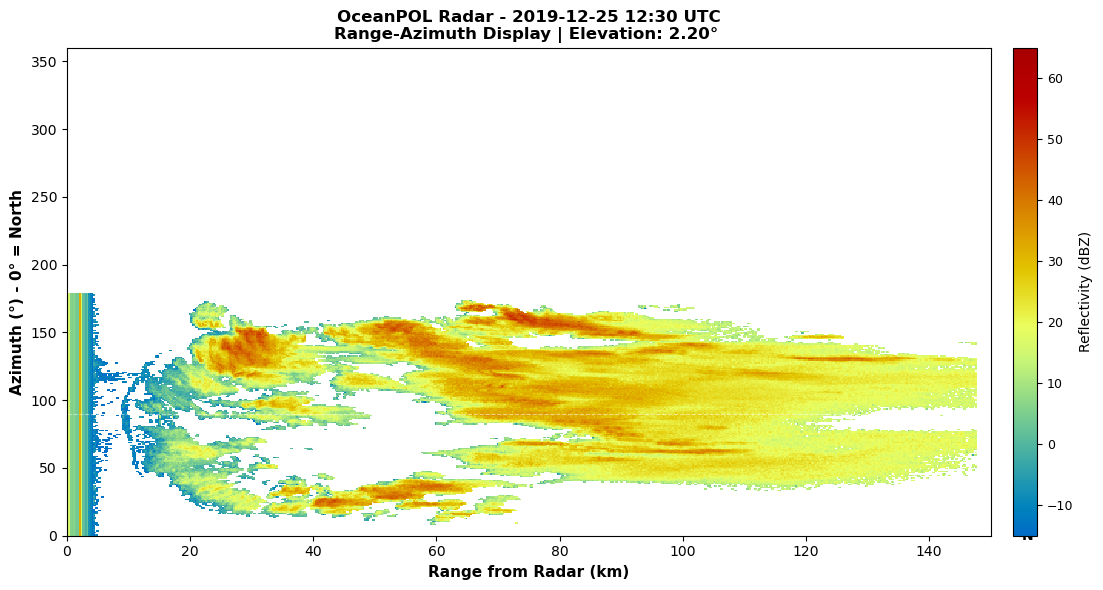

In [15]:
def plot_range_azimuth(r, azimuth, data, title_suffix="", **kwargs):
    """
    Plot data in native radar coordinates (range vs azimuth).
    """
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Create mesh and plot
    im = ax.pcolormesh(r/1000, azimuth, data, 
                       cmap=cmc.HomeyerRainbow, 
                       vmin=-15, vmax=65,
                       shading='auto')
    
    # Formatting
    ax.set_xlabel('Range from Radar (km)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Azimuth (°) - 0° = North', fontsize=11, fontweight='bold')
    ax.set_xlim(0, 150)
    ax.set_ylim(0, 360)
    
    # Add compass directions
    ax.axhline(0, color='white', linestyle='--', alpha=0.5, linewidth=0.8)
    ax.axhline(90, color='white', linestyle='--', alpha=0.5, linewidth=0.8)
    ax.axhline(180, color='white', linestyle='--', alpha=0.5, linewidth=0.8)
    ax.axhline(270, color='white', linestyle='--', alpha=0.5, linewidth=0.8)
    
    ax.text(155, 0, 'N', fontsize=10, fontweight='bold', va='center')
    ax.text(155, 90, 'E', fontsize=10, fontweight='bold', va='center')
    ax.text(155, 180, 'S', fontsize=10, fontweight='bold', va='center')
    ax.text(155, 270, 'W', fontsize=10, fontweight='bold', va='center')
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax, label='Reflectivity (dBZ)', pad=0.02)
    cbar.ax.tick_params(labelsize=9)
    
    # Title
    ax.set_title(f'OceanPOL Radar - {date.strftime("%Y-%m-%d %H:%M UTC")}\n'
                 f'Range-Azimuth Display | Elevation: {elevation:.2f}° {title_suffix}',
                 fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    return fig, ax

# Create the plot
fig, ax = plot_range_azimuth(r, radar_azi, reflectivity)
plt.show()

### 🔍 Interpretation:

- This is the "raw" radar view
- Range increases along x-axis
- Azimuth (compass direction) on y-axis
- Distorted from geographic perspective
- Useful for quality control and understanding radar sampling

---

### Step-by-Step Coordinate Transformation

In [16]:
# Step 1: Convert nautical bearing to mathematical angle
print("Step 1: Converting nautical azimuth to mathematical angle")
print("Formula: θ_math = (450° - azimuth_nautical) mod 360°")
print("\nExamples:")
for azi_nautical in [0, 90, 180, 270]:
    azi_math = (450 - azi_nautical) % 360
    direction = {0: 'North', 90: 'East', 180: 'South', 270: 'West'}[azi_nautical]
    print(f"  {direction:5s} ({azi_nautical:3d}° nautical) → {azi_math:3d}° mathematical")

# Apply transformation
azimuth = np.deg2rad((450 - radar_azi) % 360)
print("\n✓ Azimuth conversion complete")

# Step 2: Create meshgrid
print("\nStep 2: Creating coordinate meshgrid")
R, A = np.meshgrid(r, azimuth)
print(f"  Meshgrid shape: {R.shape}")

# Step 3: Convert to Cartesian coordinates
print("\nStep 3: Converting to Cartesian coordinates")
print("Formulas:")
print("  x = r × cos(θ)")
print("  y = r × sin(θ)")
x = R * np.cos(A)
y = R * np.sin(A)
print("\n✓ Cartesian coordinates calculated")
print(f"  x range: {x.min()/1000:.1f} to {x.max()/1000:.1f} km")
print(f"  y range: {y.min()/1000:.1f} to {y.max()/1000:.1f} km")

Step 1: Converting nautical azimuth to mathematical angle
Formula: θ_math = (450° - azimuth_nautical) mod 360°

Examples:
  North (  0° nautical) →  90° mathematical
  East  ( 90° nautical) →   0° mathematical
  South (180° nautical) → 270° mathematical
  West  (270° nautical) → 180° mathematical

✓ Azimuth conversion complete

Step 2: Creating coordinate meshgrid
  Meshgrid shape: (360, 600)

Step 3: Converting to Cartesian coordinates
Formulas:
  x = r × cos(θ)
  y = r × sin(θ)

✓ Cartesian coordinates calculated
  x range: -149.9 to 149.9 km
  y range: -149.9 to 149.9 km


### Visualization 2: Cartesian Display

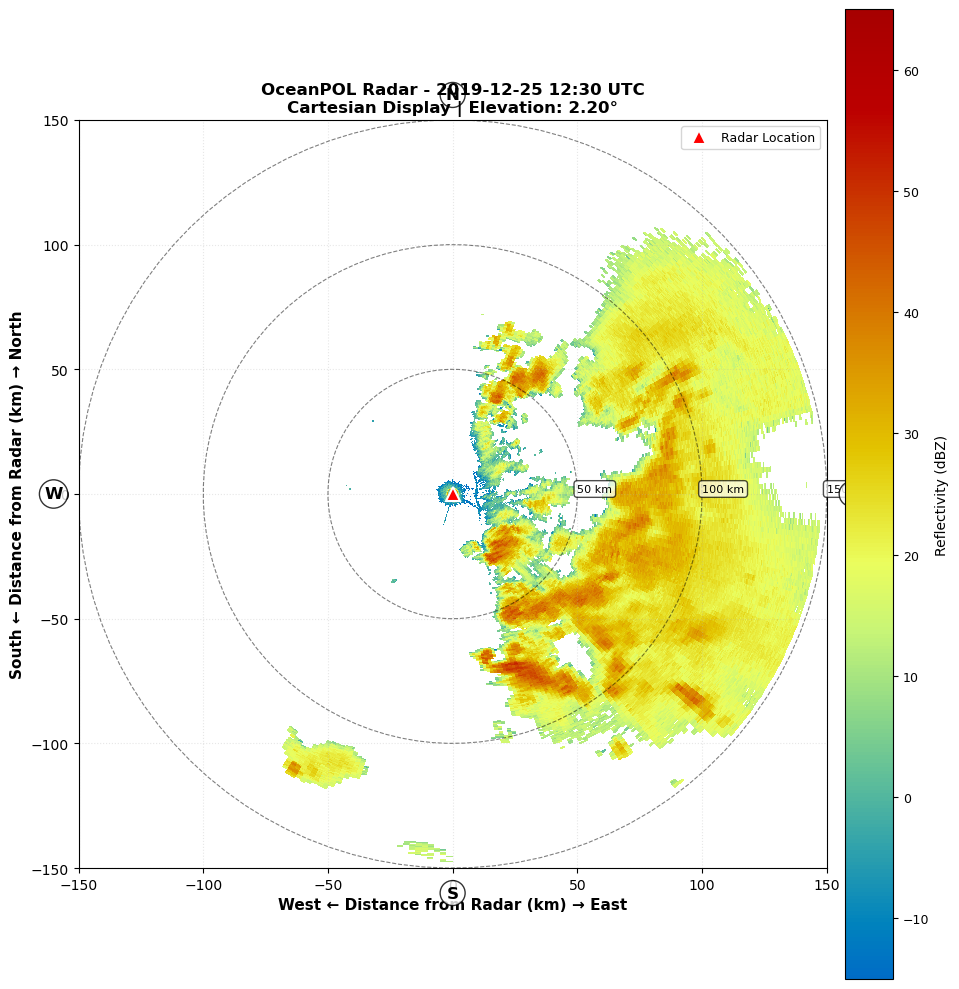

In [18]:
def plot_cartesian(x, y, data, add_compass=True, **kwargs):
    """
    Plot radar data in Cartesian coordinates.
    """
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Plot data
    im = ax.pcolormesh(x/1000, y/1000, data,
                       cmap=cmc.HomeyerRainbow,
                       vmin=-15, vmax=65,
                       shading='auto')
    
    # Add range rings
    theta = np.linspace(0, 2*np.pi, 100)
    for r_km in [50, 100, 150]:
        ax.plot(r_km * np.cos(theta), r_km * np.sin(theta),
                'k--', linewidth=0.8, alpha=0.5)
        ax.text(r_km, 0, f'{r_km} km', ha='left', va='bottom',
                fontsize=8, bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    
    # Add compass rose if requested
    if add_compass:
        compass_r = 160
        directions = {'N': (0, 1), 'E': (1, 0), 'S': (0, -1), 'W': (-1, 0)}
        for label, (dx, dy) in directions.items():
            ax.text(compass_r * dx, compass_r * dy, label,
                   ha='center', va='center', fontsize=12, fontweight='bold',
                   bbox=dict(boxstyle='circle', facecolor='white', alpha=0.8))
    
    # Formatting
    ax.set_xlabel('West ← Distance from Radar (km) → East', fontsize=11, fontweight='bold')
    ax.set_ylabel('South ← Distance from Radar (km) → North', fontsize=11, fontweight='bold')
    ax.set_xlim(-150, 150)
    ax.set_ylim(-150, 150)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3, linestyle=':')
    
    # Add radar location marker
    ax.plot(0, 0, 'r^', markersize=10, markeredgecolor='white', markeredgewidth=1.5,
            label='Radar Location')
    ax.legend(loc='upper right', fontsize=9)
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax, label='Reflectivity (dBZ)', pad=0.02)
    cbar.ax.tick_params(labelsize=9)
    
    # Title
    ax.set_title(f'OceanPOL Radar - {date.strftime("%Y-%m-%d %H:%M UTC")}\n'
                 f'Cartesian Display | Elevation: {elevation:.2f}°',
                 fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    return fig, ax

# Create the plot
fig, ax = plot_cartesian(x, y, reflectivity)
plt.show()

### 🔍 Interpretation:

- Now geographically correct
- North is up, East is right
- Range rings show distance from radar
- Easier to interpret meteorological features
- Ready to overlay on maps

---

## Part 7: Adding Geographic Context

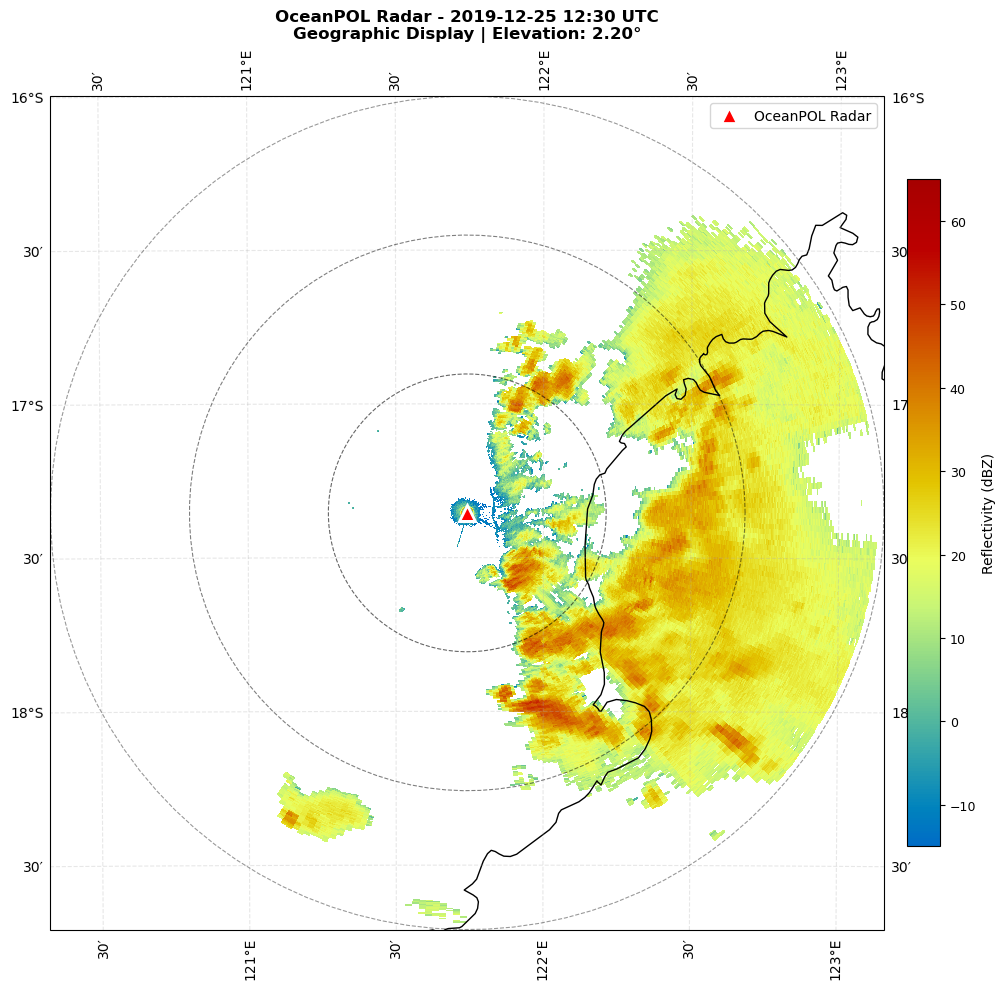

In [19]:
def plot_on_map(x, y, data, radar_obj, **kwargs):
    """
    Plot radar data on a geographic map with coastlines.
    """
    # Define map projection centered on radar
    projection = ccrs.AzimuthalEquidistant(
        central_longitude=radar_obj.longitude['data'][0],
        central_latitude=radar_obj.latitude['data'][0]
    )
    
    fig = plt.figure(figsize=(12, 10))
    ax = plt.subplot(1, 1, 1, projection=projection)
    
    # Add geographic features
    ax.coastlines('10m', linewidth=1.0, color='black')
    ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,
                 alpha=0.3, linestyle='--')
    
    # Plot radar data
    im = ax.pcolormesh(x, y, data,
                       cmap=cmc.HomeyerRainbow,
                       vmin=-15, vmax=65,
                       shading='auto')
    
    # Add range rings
    theta = np.linspace(0, 2*np.pi, 100)
    for r_m, alpha in zip([50e3, 100e3, 150e3], [0.6, 0.5, 0.4]):
        ax.plot(r_m * np.cos(theta), r_m * np.sin(theta),
                'k--', linewidth=0.8, alpha=alpha, transform=projection)
    
    # Add radar location
    ax.plot(0, 0, 'r^', markersize=12, markeredgecolor='white',
            markeredgewidth=2, transform=projection, label='OceanPOL Radar')
    
    # Set extent
    ax.set_xlim(-150e3, 150e3)
    ax.set_ylim(-150e3, 150e3)
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax, label='Reflectivity (dBZ)', 
                        pad=0.02, shrink=0.8)
    cbar.ax.tick_params(labelsize=9)
    
    # Title and legend
    ax.set_title(f'OceanPOL Radar - {date.strftime("%Y-%m-%d %H:%M UTC")}\n'
                 f'Geographic Display | Elevation: {elevation:.2f}°',
                 fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10)
    
    plt.tight_layout()
    return fig, ax

# Create the map plot
fig, ax = plot_on_map(x, y, reflectivity, radar)
plt.show()

### 🗺️ Geographic Context Benefits:

- See relationship to coastline and topography
- Identify orographic effects
- Understand land-sea interactions
- Communicate results to stakeholders
- Validate against surface observations

---

## Part 8: The Easy Way - Using Py-ART Built-in Functions

While understanding coordinate transformations is important, Py-ART provides convenient functions for visualization!

### An Overview of Py-ART Plotting Utilities

Now that we have loaded the data and inspected it, the next logical thing to do is to visualize the data! Py-ART's visualization functionality is done through the objects in the [pyart.graph](https://arm-doe.github.io/pyart/API/generated/pyart.graph.html) module.

In Py-ART there are 4 primary visualization classes in pyart.graph:

* [RadarDisplay](https://arm-doe.github.io/pyart/API/generated/pyart.graph.RadarDisplay.html)
* [RadarMapDisplay](https://arm-doe.github.io/pyart/API/generated/pyart.graph.RadarMapDisplay.html)
* [AirborneRadarDisplay](https://arm-doe.github.io/pyart/API/generated/pyart.graph.AirborneRadarDisplay.html)

Plotting grid data
* [GridMapDisplay](https://arm-doe.github.io/pyart/API/generated/pyart.graph.GridMapDisplay.html)

### Use the [RadarMapDisplay](https://arm-doe.github.io/pyart/API/generated/pyart.graph.RadarMapDisplay.html) with our data

For the this example, we will be using `RadarMapDisplay`, using Cartopy to deal with geographic coordinates.


We start by creating a figure first.

In [20]:
fig = plt.figure(figsize=[10, 10])

<Figure size 1000x1000 with 0 Axes>

Once we have a figure, let's add our `RadarMapDisplay`

In [21]:
fig = plt.figure(figsize=[10, 10])
display = pyart.graph.RadarMapDisplay(radar)

<Figure size 1000x1000 with 0 Axes>

Adding our map display without specifying a field to plot **won't do anything** we need to specifically add a field to field using `.plot_ppi_map()`

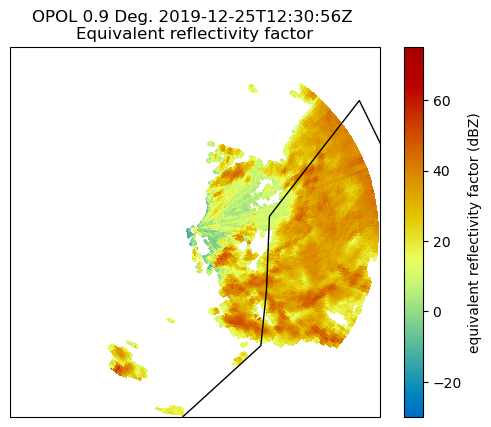

In [23]:
display.plot_ppi_map('corrected_reflectivity')

By default, it will plot the elevation scan, the the default colormap from `Matplotlib`... let's customize!

We add the following arguements:
- `sweep=3` - The fourth elevation scan (since we are using Python indexing)
- `vmin=-20` - Minimum value for our plotted field/colorbar
- `vmax=60` - Maximum value for our plotted field/colorbar
- `projection=ccrs.PlateCarree()` - Cartopy latitude/longitude coordinate system
- `cmap='pyart_HomeyerRainbow'` - Colormap to use, selecting one provided by PyART 

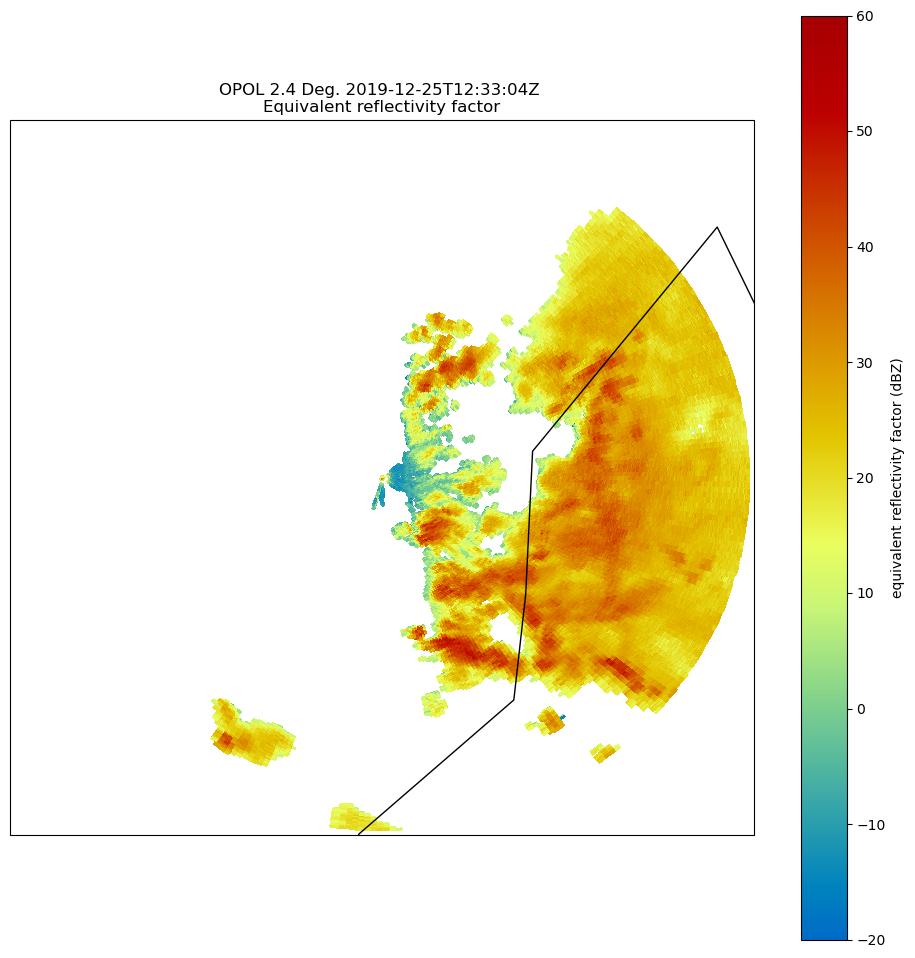

In [26]:
fig = plt.figure(figsize=[12, 12])
display = pyart.graph.RadarMapDisplay(radar)
display.plot_ppi_map('corrected_reflectivity',
                     sweep=3,
                     vmin=-20,
                     vmax=60,
                     projection=ccrs.PlateCarree(),
                     cmap=cmc.HomeyerRainbow)
plt.show()

You can change many parameters in the graph by changing the arguments to plot_ppi_map. As you can recall from earlier. simply view these arguments in a Jupyter notebook by typing:

In [27]:
display.plot_ppi_map?

Signature:
display.plot_ppi_map(
    field,
    sweep=0,
    mask_tuple=None,
    vmin=None,
    vmax=None,
    cmap=None,
    norm=None,
    mask_outside=False,
    title=None,
    title_flag=True,
    colorbar_flag=True,
    colorbar_label=None,
    colorbar_orient='vertical',
    ax=None,
    fig=None,
    lat_lines=None,
    lon_lines=None,
    projection=None,
    min_lon=None,
    max_lon=None,
    min_lat=None,
    max_lat=None,
    width=None,
    height=None,
    lon_0=None,
    lat_0=None,
    resolution='110m',
    shapefile=None,
    shapefile_kwargs=None,
    edges=True,
    gatefilter=None,
    filter_transitions=True,
    embellish=True,
    add_grid_lines=True,
    raster=False,
    ticks=None,
    ticklabs=None,
    alpha=None,
    edgecolors='face',
    **kwargs,
)
Docstring:
Plot a PPI volume sweep onto a geographic map.

Parameters
----------
field : str
    Field to plot.
sweep : int, optional
    Sweep number to plot.

Other Parameters
----------------
mask_tuple 

For example, let's change the colormap to something different

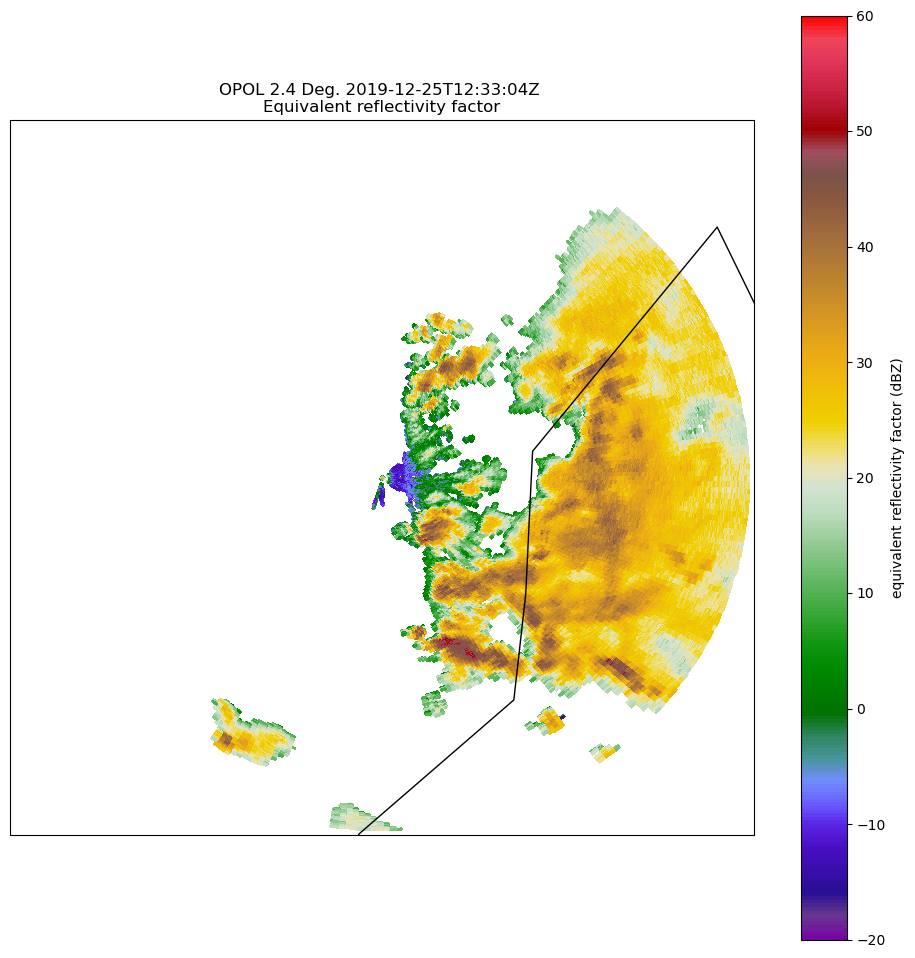

In [31]:
from cmweather.cm import Carbone42
fig = plt.figure(figsize=[12, 12])
display = pyart.graph.RadarMapDisplay(radar)
display.plot_ppi_map('corrected_reflectivity',
                     sweep=3,
                     vmin=-20,
                     vmax=60,
                     projection=ccrs.PlateCarree(),
                     cmap=Carbone42)
plt.show()

Or, let's view a different elevation scan! To do this, change the sweep parameter in the plot_ppi_map function.

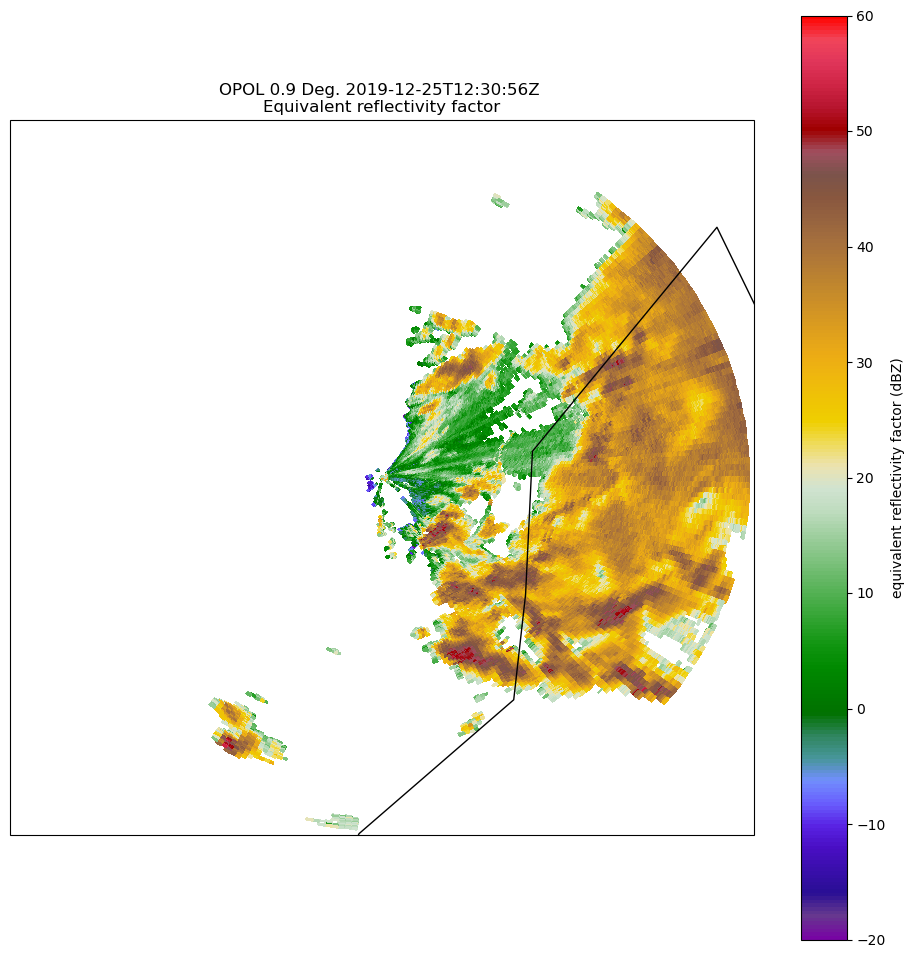

In [33]:
fig = plt.figure(figsize=[12, 12])
display = pyart.graph.RadarMapDisplay(radar)
display.plot_ppi_map('corrected_reflectivity',
                     sweep=0,
                     vmin=-20,
                     vmax=60,
                     projection=ccrs.PlateCarree(),
                     cmap=Carbone42)
plt.show()

Let's take a look at a different field - for example, correlation coefficient (`corr_coeff`)

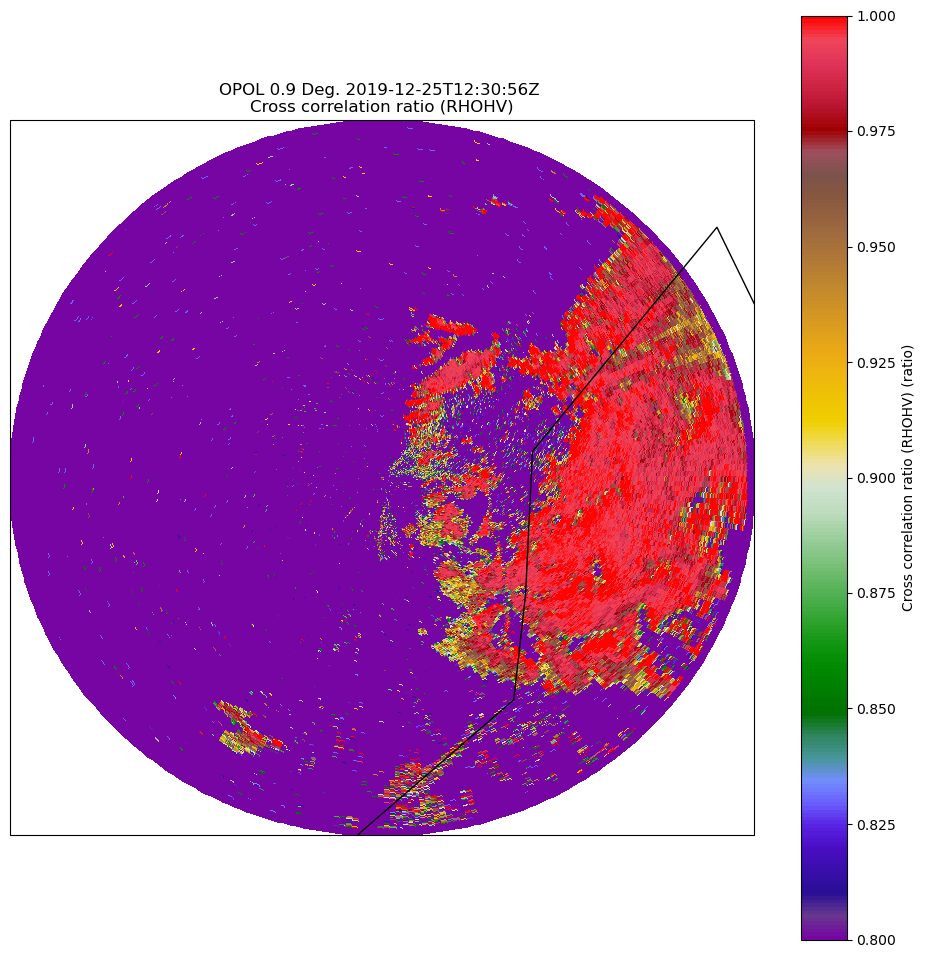

In [34]:
fig = plt.figure(figsize=[12, 12])
display = pyart.graph.RadarMapDisplay(radar)
display.plot_ppi_map('cross_correlation_ratio',
                     sweep=0,
                     vmin=0.8,
                     vmax=1.,
                     projection=ccrs.PlateCarree(),
                     cmap=Carbone42)
plt.show()

# Exercise

In the data directory you will find the file `"data/63_20251122_050000.pvol.h5"` that is Tropical Cyclone Fina from Berrimah's radar (Darwin, Northern territory). To open this file use:

```radar = pyart.aux_io.read_odim_h5("data/63_20251122_050000.pvol.h5", file_field_names=True)```

Plot the tropical cyclone on a nice map! (On modern operational radar, the first sweep is the highest elevation scan, the last sweep is the lowest elevation. Plot the last sweep.)

| Acronym | Name | 
| --- | --- |
| TH | Reflectivity (as measured by the radar) |
| DBZH | Corrected reflectivity |
| DBZH_CLEAN | Corrected reflectivity (removed clutter) |
| VRADH | Doppler velocity |
| VRADDH | Corrected Doppler velocity (corrected for folding) |

In [ ]:
# Google Colab only:
!wget 'https://raw.githubusercontent.com/vlouf/monash-radar-workshop-2025/main/01-Introduction/data/63_20251122_050000.pvol.h5'

In [ ]:
radar = pyart.aux_io.read_odim_h5("63_20251122_050000.pvol.h5", file_field_names=True)
print(radar.fields.keys())

dict_keys(['DBZH', 'VRADH', 'WRADH', 'TH', 'QCFLAGS', 'DBZH_CLEAN', 'VRADDH'])


---
## Summary
Within this notebook, we covered the basics of working with radar data using `pyart`, including:
- Reading in a file using `pyart.io`
- Investigating the `Radar` object
- Visualizing radar data using the `RadarMapDisplay`